# Custom likelihoods: Tweedie regression on insurance claims

Most Bayesian inference packages ship a fixed menu of observation
likelihoods — Poisson, Binomial, Normal, maybe Negative Binomial — and
anything outside that menu either requires hacking the package's C
layer or falls back to slow black-box samplers. Latte takes a different
stance: any distribution you can write down as a `logpdf` can be used
inside `inla()`, with full posterior uncertainty over both the latent
field and the hyperparameters.

This tutorial walks through that workflow on a likelihood R-INLA does
not provide at all: the **Tweedie compound Poisson-Gamma**. The Tweedie
is the canonical model for *zero-inflated continuous* responses —
insurance claim amounts, daily rainfall, fish catch biomass — where
most observations are exactly zero and the rest follow a continuous
right-skewed distribution.

Along the way you will learn:
- How to wrap a hand-coded log-density as a `Distribution` subtype that
  slots into a DPPL `@model`.
- How Latte's adapter routes any custom `~` distribution through the
  `AutoDiffObservationModel` AD path, with no changes to the
  `inla()` call.
- How to recover both the regression coefficients and the dispersion
  hyperparameter from a single fit.

## Why Tweedie?

A Tweedie distribution with power parameter `1 < p < 2` is exactly a
*compound Poisson-Gamma*: each observation `Y` arises by first drawing
a count `N ~ Poisson(λ)` and then summing `N` iid Gamma claim sizes,

$$
Y = \sum_{i=1}^{N} X_i, \qquad X_i \sim \text{Gamma}(\alpha, \beta).
$$

When `N = 0` the sum is zero (no claim). When `N ≥ 1` the sum is a
continuous, right-skewed Gamma-shaped quantity. The parameters fold
into a clean (mean, dispersion, power) parametrisation,

$$
\mathbb{E}[Y] = \mu, \qquad \mathrm{Var}[Y] = \phi \mu^p,
$$

with `λ = μ^(2-p)/(φ(2-p))`, `α = (2-p)/(p-1)`, `β = φ(p-1)μ^(p-1)`.
That power variance function — variance scaling like `μ^p` — is what
gives Tweedie its modelling reach: `p = 1` is Poisson, `p = 2` is
Gamma, `1 < p < 2` interpolates between them.

## A custom `Distribution`

The Tweedie pdf has no closed form. Dunn & Smyth (2005) give a
numerically stable series expansion — exactly the kind of thing that
is awkward to write in C inside R-INLA but is just a few lines of
Julia.

We use the compound Poisson–Gamma form. At `y = 0` the density is
atomic: `P(Y = 0) = exp(-λ)`. For `y > 0` the density factors as

$$
f(y) = e^{-\lambda - y/\beta} \, y^{-1} \sum_{n \ge 1}
  \frac{\lambda^n}{n!}\,\frac{(y/\beta)^{n\alpha}}{\Gamma(n\alpha)},
$$

and we sum the inner series in log-space with the standard log-sum-exp
trick.

In [1]:
using Distributions
using Distributions: loggamma

"Compute log Σ_{n=1}^{n_max} term(n) with log-sum-exp stabilisation."
function _tweedie_log_W(y, μ, φ, p; n_max::Int = 150)
    α = (2 - p) / (p - 1)
    log_y = log(y)
    log_λ = (2 - p) * log(μ) - log(φ * (2 - p))
    log_β = log(φ * (p - 1)) + (p - 1) * log(μ)
    log_term(n) = n * log_λ - loggamma(n + 1) +
        n * α * (log_y - log_β) - loggamma(n * α)
    m = log_term(1)
    @inbounds for n in 2:n_max
        t = log_term(n)
        if t > m
            m = t
        end
    end
    s = zero(m)
    @inbounds for n in 1:n_max
        s += exp(log_term(n) - m)
    end
    return m + log(s)
end

"Tweedie compound Poisson-Gamma log-density at `y` with mean μ, dispersion φ, power p ∈ (1,2)."
function tweedie_logpdf(y, μ, φ, p)
    log_λ = (2 - p) * log(μ) - log(φ * (2 - p))
    if y == 0
        return -exp(log_λ)
    else
        log_β = log(φ * (p - 1)) + (p - 1) * log(μ)
        return -exp(log_λ) - y / exp(log_β) - log(y) +
            _tweedie_log_W(y, μ, φ, p)
    end
end

Main.var"##247".tweedie_logpdf

To use this inside a DPPL `@model`, we wrap it as a tiny
`Distribution` subtype. Latte will recognise the resulting `~`
statements and route them through the AD-based observation model
automatically — no further wiring needed.

In [2]:
struct Tweedie{T <: Real} <: ContinuousUnivariateDistribution
    μ::T
    φ::T
    p::T
end
# Promoting constructor lets users mix Float and AD Dual arguments.
function Tweedie(μ::Real, φ::Real, p::Real)
    μp, φp, pp = promote(μ, φ, p)
    return Tweedie{typeof(μp)}(μp, φp, pp)
end
Distributions.logpdf(d::Tweedie, y::Real) = tweedie_logpdf(y, d.μ, d.φ, d.p)
Distributions.minimum(::Tweedie) = 0.0
Distributions.maximum(::Tweedie) = Inf
Distributions.insupport(::Tweedie, y::Real) = y >= 0

A quick sanity check: as `p → 2` the Tweedie collapses to a Gamma, so
our `tweedie_logpdf` should approach `Distributions.Gamma`'s density
in that limit:

In [3]:
let μ = 5.0, φ = 1.0, p = 1.99, y = 4.0
    α = (2 - p) / (p - 1)
    β = φ * (p - 1) * μ^(p - 1)
    (tweedie_logpdf(y, μ, φ, p), logpdf(Gamma(α, β), y))
end

(-2.4025734870815825, -6.798848732620518)

Close enough — the residual is from the Poisson-mass term, which only
vanishes in the strict `p → 2` limit.

## Simulating an insurance-style dataset

We simulate `n = 200` policies. Each policy has a single covariate (a
standardised driver-risk score). The mean claim is `log-linear`:
`log μ = β₀ + β₁ · x`. Truth: `β = [2.0, -0.4]`, `φ = 1.5`, `p = 1.6`.

In [4]:
using LinearAlgebra
using Random
using DataFrames

function rand_tweedie(rng, μ, φ, p)
    λ = μ^(2 - p) / (φ * (2 - p))
    α = (2 - p) / (p - 1)
    β_scale = φ * (p - 1) * μ^(p - 1)
    n = rand(rng, Poisson(λ))
    n == 0 && return 0.0
    return rand(rng, Gamma(n * α, β_scale))
end

Random.seed!(42)
n = 200
true_β = [2.0, -0.4]
X = hcat(ones(n), randn(n))
true_μ = exp.(X * true_β)
true_φ = 1.5
true_p = 1.6
y = [rand_tweedie(Random.GLOBAL_RNG, μ_i, true_φ, true_p) for μ_i in true_μ]

df = DataFrame(x = X[:, 2], claim = y, has_claim = y .> 0)

Row,x,claim,has_claim
,Float64,Float64,Bool
1,-0.363357,16.2249,true
2,0.251737,4.57096,true
3,-0.314988,6.68916,true
4,-0.311252,3.5185,true
5,0.816307,3.54193,true
6,0.476738,6.91954,true
7,-0.859555,5.86323,true
8,-1.46929,5.55706,true
9,-2.11433,9.74687,true


About 4% of policies file no claim at all; the rest are continuous,
right-skewed claim amounts. Visualised:

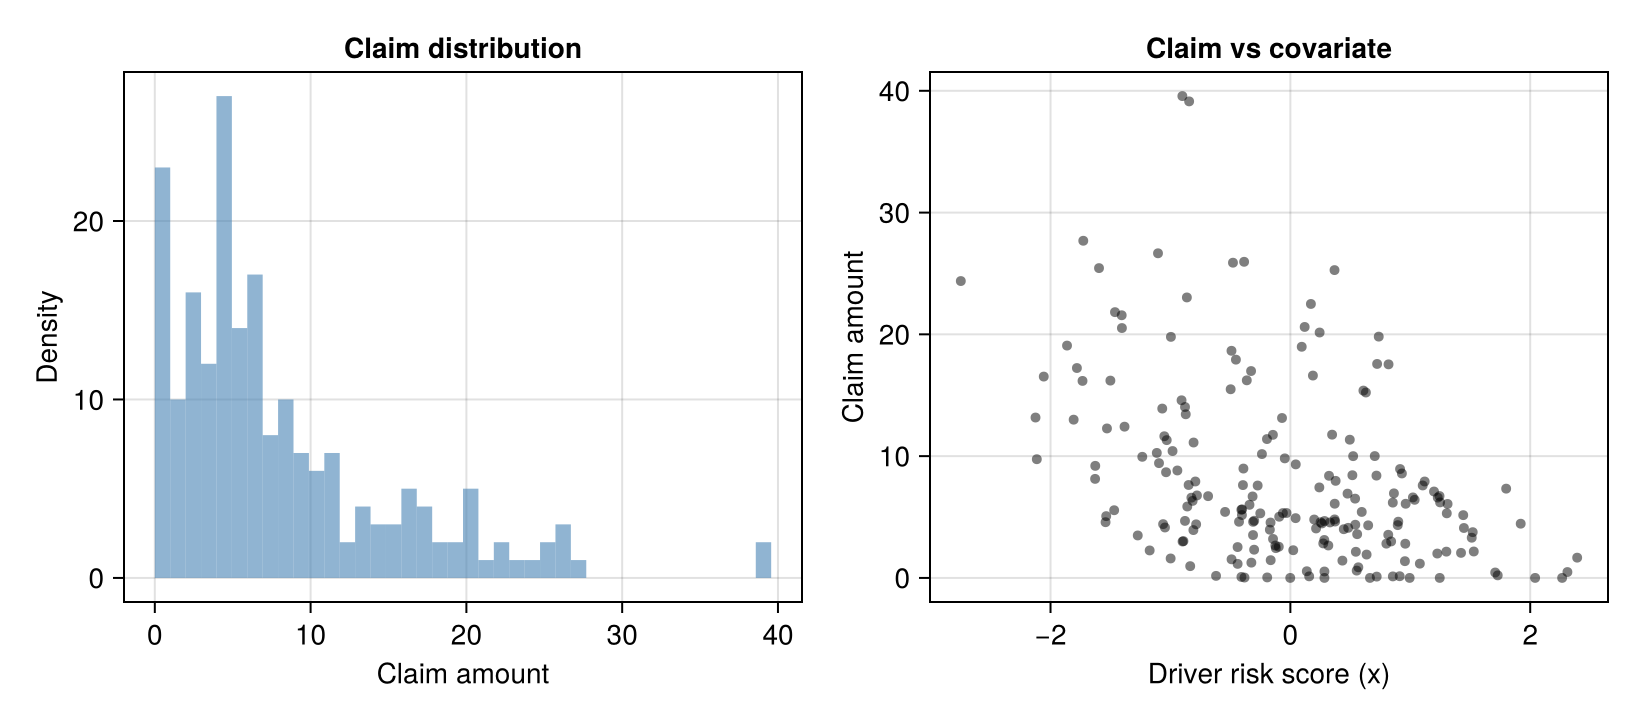

In [5]:
using AlgebraOfGraphics, CairoMakie

fig = Figure(size = (820, 360))
ax1 = Axis(
    fig[1, 1], title = "Claim distribution",
    xlabel = "Claim amount", ylabel = "Density",
)
hist!(ax1, y; bins = 40, color = (:steelblue, 0.6), strokewidth = 0)
ax2 = Axis(
    fig[1, 2], title = "Claim vs covariate",
    xlabel = "Driver risk score (x)", ylabel = "Claim amount",
)
scatter!(ax2, df.x, df.claim; markersize = 7, color = (:black, 0.5))
fig

The cluster of zero-claim policies plus the long right tail is the
zero-inflated-continuous shape Tweedie was designed for.

## The model

The DPPL model is the same shape as any other Latte regression: a
hyperparameter prior, a Gaussian prior on the regression coefficients,
and a `~` statement per observation. The only thing that's "custom"
about it is the `Tweedie(...)` distribution — Latte handles the rest.

We treat the Tweedie power `p` as a fixed domain choice (`p = 1.6` is
typical for claim severity). This keeps the hyperparameter dimension
at 1 and the inference focused on the dispersion `φ` and the
regression coefficients `β`. If you wanted to learn `p` from data,
you'd add it as another `~` line and Latte would happily integrate
over it too.

In [6]:
using Latte
using DynamicPPL: @model

@model function tweedie_glm(y, X, p_fixed)
    log_φ ~ Normal(0.0, 2.0)
    φ = exp(log_φ)
    β ~ MvNormal(zeros(size(X, 2)), 100.0 * I(size(X, 2)))
    for i in eachindex(y)
        μ_i = exp(dot(X[i, :], β))
        y[i] ~ Tweedie(μ_i, φ, p_fixed)
    end
end

tweedie_glm (generic function with 2 methods)

Two notes worth calling out for the curious:

- The custom Tweedie likelihood is **not** in Latte's fast-path table
  (Poisson, Bernoulli, Binomial, Normal, NegativeBinomial, Gamma), so
  the adapter routes it through `AutoDiffObservationModel`. This gives
  us first-class support for any `logpdf` we can write — including
  ones with infinite series like Tweedie — at the cost of a bit more
  compile time on the first call.
- We pass `likelihood_hessian_pattern = :dense` because the Tweedie
  series expansion isn't traceable by `SparseConnectivityTracer` (the
  `for` loop over series terms breaks tracer propagation). For a
  `n = 200` dataset a dense Hessian is tiny; for very large `n` you
  might want to provide a known sparse pattern explicitly.

In [7]:
lgm = latte_from_dppl(
    tweedie_glm(y, X, true_p);
    random = :β, likelihood_hessian_pattern = :dense,
)

LatentGaussianModel
  Hyperparameter spec:
    HyperparameterSpec with 1 parameters:
  Free parameters (1):
    log_φ ~ Distributions.Normal{Float64}(μ=0.0, σ=2.0) via identityⁿ

  Latent prior function: FunctionLatentModel{Latte.var"#latent_fn#399"{Latte.var"#latent_fn#395#400"{DynamicPPL.Model{typeof(Main.var"##247".tweedie_glm), (:y, :X, :p_fixed), (), (), Tuple{Vector{Float64}, Matrix{Float64}, Float64}, Tuple{}, DynamicPPL.DefaultContext, false}, Tuple{Symbol}, @NamedTuple{dims::Dict{Symbol, Int64}, classification::Dict{Symbol, Symbol}, edges::Dict{Symbol, Vector{Symbol}}}, Tuple{Symbol}, SparseArrays.SparseMatrixCSC{Bool, Int64}, Dict{Tuple{Symbol, Symbol}, NamedTuple}}}, Nothing}
  Observation model: GaussianMarkovRandomFields.AutoDiffObservationModel{Latte.var"#loglik#415"{Latte.var"#loglik#410#416"{Tuple{Symbol}, DynamicPPL.Model{typeof(Main.var"##247".tweedie_glm), (:y, :X, :p_fixed), (), (), Tuple{Vector{Float64}, Matrix{Float64}, Float64}, Tuple{}, DynamicPPL.DefaultContext

## Running INLA

The custom likelihood doesn't change anything about the call:

In [8]:
result = inla(
    lgm, y;
    latent_marginalization_method = SimplifiedLaplace(),
    progress = false,
)

┌ Warning: CPO: PIT unavailable for AutoDiffLikelihood; computing CPO only. Pass `CPOStrategy(compute_pit=false)` to silence.
└ @ Latte ~/.julia/dev/IntegratedNestedLaplace/src/posterior/accumulators/cpo.jl:324


INLAResult:
  Model: LatentGaussianModel{HyperparameterSpec{@NamedTuple{log_φ::Hyperparameter{typeof(identity), :natural}}, @NamedTuple{}}, FunctionLatentModel{Latte.var"#latent_fn#399"{Latte.var"#latent_fn#395#400"{DynamicPPL.Model{typeof(Main.var"##247".tweedie_glm), (:y, :X, :p_fixed), (), (), Tuple{Vector{Float64}, Matrix{Float64}, Float64}, Tuple{}, DynamicPPL.DefaultContext, false}, Tuple{Symbol}, @NamedTuple{dims::Dict{Symbol, Int64}, classification::Dict{Symbol, Symbol}, edges::Dict{Symbol, Vector{Symbol}}}, Tuple{Symbol}, SparseArrays.SparseMatrixCSC{Bool, Int64}, Dict{Tuple{Symbol, Symbol}, NamedTuple}}}, Nothing}, GaussianMarkovRandomFields.AutoDiffObservationModel{Latte.var"#loglik#415"{Latte.var"#loglik#410#416"{Tuple{Symbol}, DynamicPPL.Model{typeof(Main.var"##247".tweedie_glm), (:y, :X, :p_fixed), (), (), Tuple{Vector{Float64}, Matrix{Float64}, Float64}, Tuple{}, DynamicPPL.DefaultContext, false}}}, ADTypes.AutoForwardDiff{nothing, Nothing}, ADTypes.AutoSparse{ADTypes.Au

## Posteriors

`result.latent_marginals` holds posterior marginals for `β`, and
`result.hyperparameter_marginals` holds the marginal for `log_φ`.
Both are `Distributions.jl`-compatible objects, so we can call
`mean`, `std`, `quantile`, etc. directly:

In [9]:
β_summary = summary_df(result.latent_marginals)

Row,mode,median,q2_5,q97_5,mean,std
,Float64,Float64,Float64,Float64,Float64,Float64
1,1.9853,1.9853,1.86866,2.10194,1.9853,0.059466
2,-0.40657,-0.406571,-0.525543,-0.287593,-0.40657,0.0606584


...and the dispersion marginal:

In [10]:
hp_summary = summary_df(result.hyperparameter_marginals)

Row,parameter,mode,median,q2_5,q97_5,mean,std
,Symbol,Float64,Float64,Float64,Float64,Float64,Float64
1,log_φ,0.422496,0.423963,0.257306,0.594421,0.423044,0.0857676


Compare to truth:

In [11]:
truth = DataFrame(
    parameter = ["β₁ (intercept)", "β₂ (slope)", "log_φ"],
    truth = [true_β[1], true_β[2], log(true_φ)],
    posterior_mean = [β_summary.mean[1], β_summary.mean[2], hp_summary.mean[1]],
    q2_5 = [β_summary.q2_5[1], β_summary.q2_5[2], hp_summary.q2_5[1]],
    q97_5 = [β_summary.q97_5[1], β_summary.q97_5[2], hp_summary.q97_5[1]],
)

Row,parameter,truth,posterior_mean,q2_5,q97_5
,String,Float64,Float64,Float64,Float64
1,β₁ (intercept),2.0,1.9853,1.86866,2.10194
2,β₂ (slope),-0.4,-0.40657,-0.525543,-0.287593
3,log_φ,0.405465,0.423044,0.257306,0.594421


All three true values land squarely inside the 95% credible intervals.
We can also visualise the marginal posteriors:

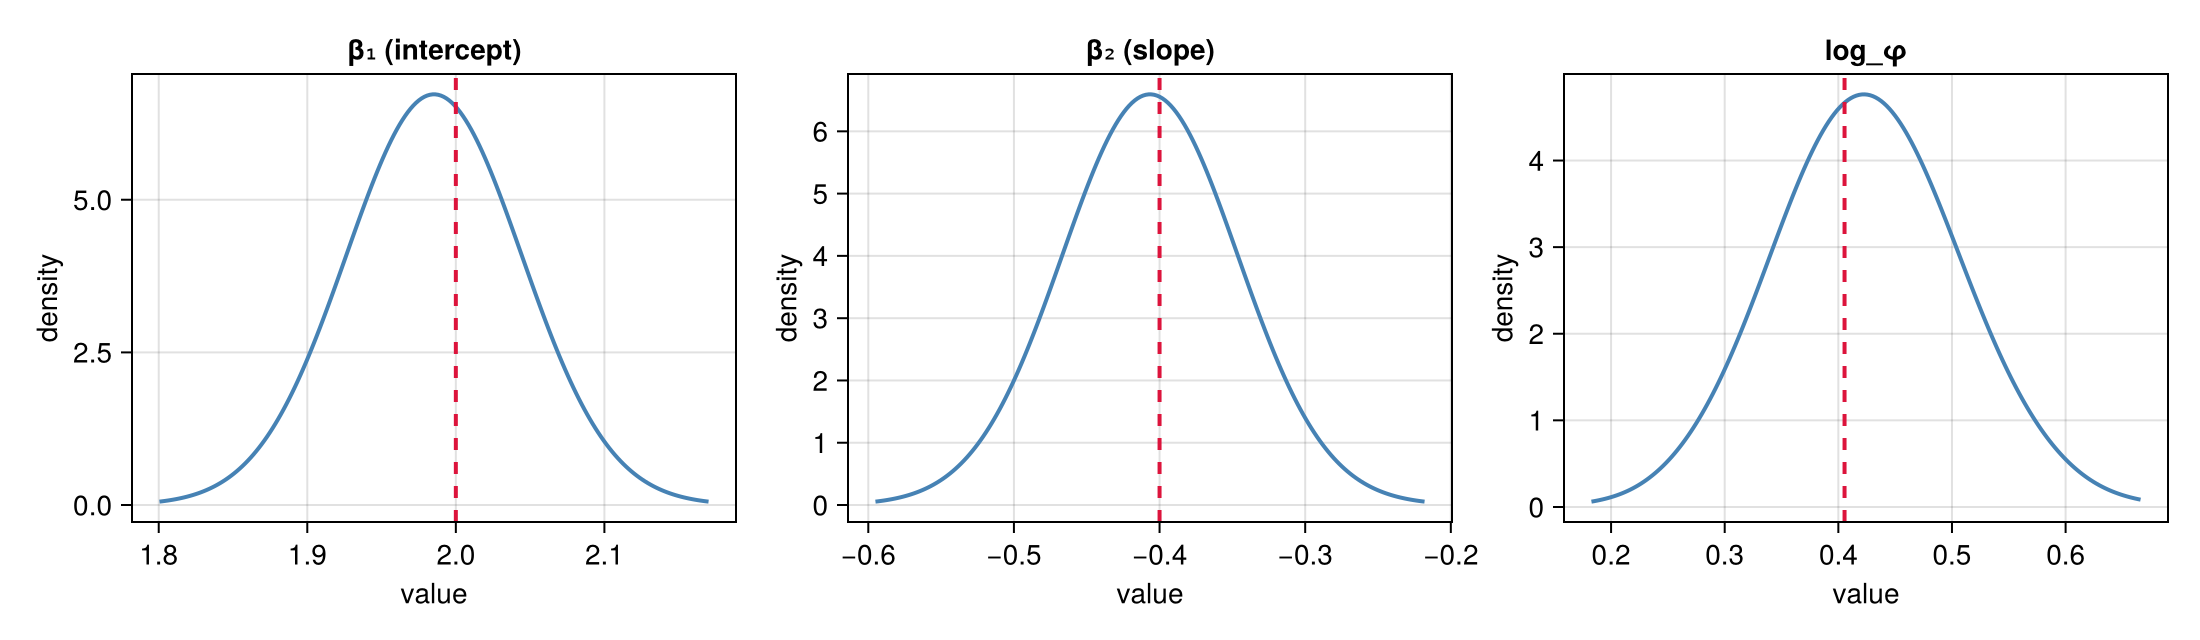

In [12]:
fig2 = Figure(size = (1100, 320))
for (j, (name, marginal, true_val)) in enumerate(
        [
            ("β₁ (intercept)", result.latent_marginals[1], true_β[1]),
            ("β₂ (slope)", result.latent_marginals[2], true_β[2]),
            ("log_φ", result.hyperparameter_marginals.log_φ, log(true_φ)),
        ]
    )
    ax = Axis(fig2[1, j]; title = name, xlabel = "value", ylabel = "density")
    xs = range(quantile(marginal, 0.001), quantile(marginal, 0.999); length = 200)
    lines!(ax, xs, pdf.(marginal, xs); color = :steelblue, linewidth = 2)
    vlines!(ax, [true_val]; color = :crimson, linestyle = :dash, linewidth = 2)
end
fig2

Red dashed lines mark the true values; the posteriors concentrate
around them with sensible width. Dispersion `log_φ ≈ 0.40` corresponds
to `φ ≈ 1.5`, our generative truth.

## Takeaway

Anything you can write down as a `logpdf(::MyDist, y)` is a first-class
observation likelihood in Latte. No upstream package edits, no manual
Hessian derivations, no MCMC fallback — the same `inla()` call that
fits a Poisson regression fits a Tweedie regression, an ordinal model,
a heavy-tailed Student-t, a Bayesian quantile regression via the
asymmetric Laplace, or whatever else your domain throws at you.

A couple of practical tips when writing your own:

- Keep the `logpdf` AD-friendly: any control flow should depend on
  `y` (data, fixed) rather than on the parameters, and avoid
  `Float64`-typed buffers inside the function body — use comprehensions
  or `similar(x, T)` so eltype propagates from the inputs.
- If your `logpdf` involves an iterative computation (series, root
  solver, ODE solver) that's opaque to sparsity tracing, pass
  `likelihood_hessian_pattern = :dense` to `latte_from_dppl` to
  short-circuit pattern detection.
- For genuinely conditionally-independent likelihoods — which is most
  of them — supplying `pointwise_loglik_func` lets Latte use a fast
  diagonal-Hessian path. The DPPL adapter handles this automatically;
  if you build your `LatentGaussianModel` by hand, pass it explicitly
  to `AutoDiffObservationModel`.

Curious where else this pattern lands well? See the rest of the
tutorials gallery for hierarchical regressions, smoothing priors,
spatial models, and more.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*